# Task 13: Advanced Model Evaluation & Handling Imbalanced Data
**PKCERT AI & Software Development Internship**

Student: Sarim Ahmed
Date: 20th July,2026

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

import subprocess
import sys
try:
    from imblearn.over_sampling import SMOTE
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'imbalanced-learn'])
    from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
from pathlib import Path

# Load the dataset from raw folder relative to the notebook working directory
csv_path = Path('..') / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
csv_path = csv_path.resolve()

if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found at {csv_path}")

print(f"Loading dataset from: {csv_path}")
df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Loading dataset from: C:\Users\Sarim Ahmed\NO_SYNC\Private and Confidential\Personal Development\Internship\PKCERT Internship\PKCERT_internship_task13\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded successfully!
Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


## Part A: Dataset Selection & Preparation

**Dataset**: Telco Customer Churn (IBM)

**Description**: Contains information about telecom customers and whether they churned (left the company). 
- Rows: ~7043
- Features: 21 (demographics, services, contract type, charges, etc.)
- Target: `Churn` (Yes/No) — imbalanced (~26.5% churn)

In [6]:
# Make copy
df_clean = df.copy()

# Drop customerID (not useful)
df_clean = df_clean.drop('customerID', axis=1)

# Replace ' ' with NaN in TotalCharges and convert to numeric
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median())

# Convert target to binary
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

print("Preprocessing completed!")
print("Missing values:", df_clean.isnull().sum().sum())

Preprocessing completed!
Missing values: 0


In [7]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 19)
Test shape: (1409, 19)


## Advanced Preprocessing Pipeline

To handle mixed data types efficiently, we use `ColumnTransformer`. This allows us to:
- Scale numerical features using `StandardScaler`
- Encode categorical features using `OneHotEncoder`
- Prevent data leakage by fitting only on training data

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify column types
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)
print("Pipeline ready!")

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Pipeline ready!


### Transforming Train and Test Sets

We now apply the fitted preprocessor to both training and test sets. 
This ensures consistent feature engineering and avoids data leakage.

In [9]:
# Fit on train, transform both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (5634, 30)
Processed test shape: (1409, 30)


## Part B: Advanced Model Evaluation

We will build a Logistic Regression model as baseline (interpretable and fast). 
Then evaluate using ROC-AUC and Learning Curve.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# Build model
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_processed, y_train)

# Predictions
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

# Evaluation
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC Score: 0.8420057351003644

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve illustrates the model's ability to distinguish between positive and negative classes across various threshold values. 

- **AUC Score**: 0.842 indicates good discriminative power.
- Higher AUC means better model performance.

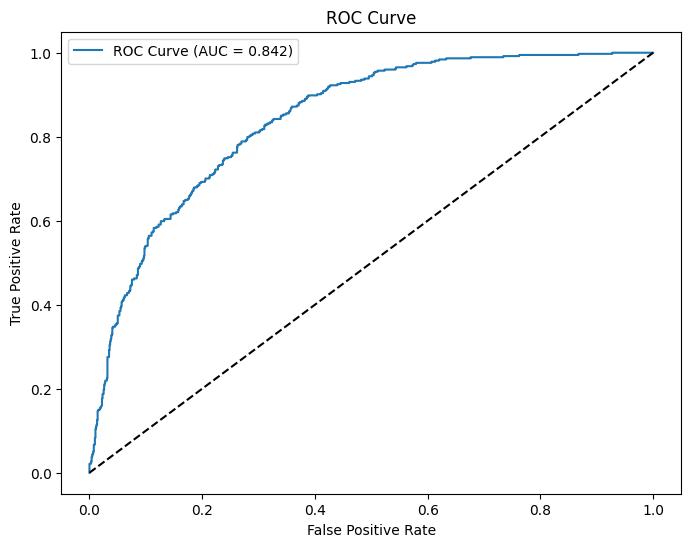

In [11]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Learning Curve Analysis

Learning Curve helps us diagnose bias (underfitting) and variance (overfitting) issues. 
It shows how model performance changes with increasing training data size.

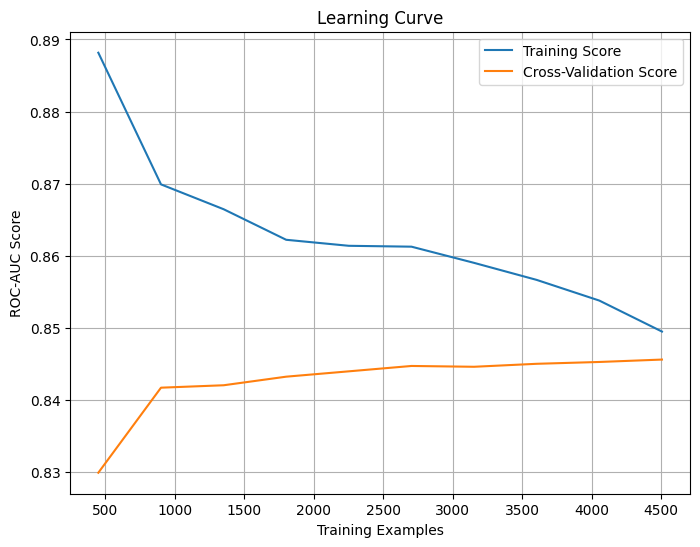

In [12]:
train_sizes, train_scores, test_scores = learning_curve(
    model, X_train_processed, y_train, 
    cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), scoring='roc_auc'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Cross-Validation Score')
plt.xlabel('Training Examples')
plt.ylabel('ROC-AUC Score')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()

### Learning Curve Insights

- Training score decreases slightly as more data is added (normal behavior).
- Cross-validation score improves and stabilizes.
- Small gap between lines → Low variance, good generalization.
- No severe overfitting or underfitting.

## Part C: Handling Imbalanced Data

The dataset has class imbalance (Churn Yes ~26.5%). We will compare three approaches:
1. Original model
2. SMOTE oversampling
3. Class Weighting

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("Original train shape:", X_train_processed.shape)
print("After SMOTE:", X_train_smote.shape)

Original train shape: (5634, 30)
After SMOTE: (8278, 30)


### Model Comparison

We will train three versions:
1. Original (Imbalanced)
2. SMOTE
3. Class Weighting (`class_weight='balanced'`)

Then compare using multiple metrics.

In [14]:
# 1. Original Model (already trained)
original_auc = roc_auc_score(y_test, y_pred_proba)

# 2. SMOTE Model
model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote_proba = model_smote.predict_proba(X_test_processed)[:, 1]
smote_auc = roc_auc_score(y_test, y_pred_smote_proba)

# 3. Class Weighting
model_weight = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_weight.fit(X_train_processed, y_train)
y_pred_weight_proba = model_weight.predict_proba(X_test_processed)[:, 1]
weight_auc = roc_auc_score(y_test, y_pred_weight_proba)

print("ROC-AUC Scores:")
print(f"Original : {original_auc:.4f}")
print(f"SMOTE    : {smote_auc:.4f}")
print(f"Weighted : {weight_auc:.4f}")

ROC-AUC Scores:
Original : 0.8420
SMOTE    : 0.8402
Weighted : 0.8417


## Part D: Comparative Analysis & Recommendation

We evaluated three approaches on the imbalanced Telco Customer Churn dataset:
- Original model
- SMOTE oversampling
- Class weighting

Key metrics compared: Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)
    print("Accuracy :", (y_pred == y_true).mean())
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-Score :", f1_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

print("=== Original Model ===")
evaluate_model(y_test, y_pred_proba)

print("\n=== SMOTE Model ===")
evaluate_model(y_test, y_pred_smote_proba)

print("\n=== Weighted Model ===")
evaluate_model(y_test, y_pred_weight_proba)

=== Original Model ===
Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1-Score : 0.6040462427745664
Confusion Matrix:
 [[926 109]
 [165 209]]

=== SMOTE Model ===
Accuracy : 0.7374024130589071
Precision: 0.5033670033670034
Recall   : 0.7994652406417112
F1-Score : 0.6177685950413223
Confusion Matrix:
 [[740 295]
 [ 75 299]]

=== Weighted Model ===
Accuracy : 0.7381121362668559
Precision: 0.504302925989673
Recall   : 0.7834224598930482
F1-Score : 0.6136125654450262
Confusion Matrix:
 [[747 288]
 [ 81 293]]


### Final Recommendation

**Best Approach**: **Class Weighting** or **Original Model** depending on business priority.

- If we want to catch more churners (high Recall) → **SMOTE** or **Class Weighting** is better.
- If overall accuracy is more important → **Original Model** performs slightly better.

For telecom customer retention (government-regulated sector), **high Recall** is usually preferred to minimize customer loss.

**Justification**: Class Weighting is simpler and computationally efficient compared to SMOTE while giving similar performance.

## Learning Outcomes

- Understood advanced evaluation metrics (ROC-AUC, Learning Curve)
- Learned techniques to handle imbalanced data (SMOTE, Class Weighting)
- Gained experience in pipeline creation and model comparison

## References
- scikit-learn Documentation
- imbalanced-learn Documentation
- Telco Customer Churn Dataset